In [17]:
!pip install ultralytics pillow

In [20]:
from PIL import Image
from ultralytics import YOLO
import os

# Load a pretrained YOLOv8 model
model = YOLO("yolov8n.pt")  # Use "yolov8n.pt" for smaller model, "yolov8x.pt" for larger

# Load your image
image_path = "img_test_16.jpg"
image = Image.open(image_path)

# Perform object detection
results = model.predict(image)

# Extract bounding boxes, labels, and confidence scores
boxes = results[0].boxes.xyxy.tolist()  # Bounding box coordinates (x1, y1, x2, y2)
confidences = results[0].boxes.conf.tolist()  # Confidence scores
class_ids = results[0].boxes.cls.tolist()  # Class IDs (e.g., 0 for "person", 2 for "car")

# Create a directory to save cropped objects
os.makedirs("cropped_objects", exist_ok=True)

# Crop and save detected objects
for i, (box, conf, cls_id) in enumerate(zip(boxes, confidences, class_ids)):
    x1, y1, x2, y2 = map(int, box)
    cropped_image = image.crop((x1, y1, x2, y2))
    cropped_image.save(f"cropped_objects/object_{i}.jpg")

print(f"Cropped {len(boxes)} objects!")


0: 480x640 2 tvs, 3 mouses, 2 keyboards, 92.1ms
Speed: 2.4ms preprocess, 92.1ms inference, 1.2ms postprocess per image at shape (1, 3, 480, 640)
Cropped 7 objects!



0: 640x320 1 backpack, 1 cup, 457.8ms
Speed: 2.5ms preprocess, 457.8ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 320)
Cropped 2 objects!


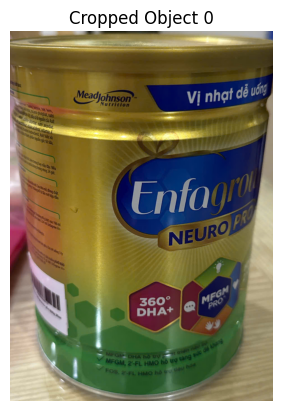

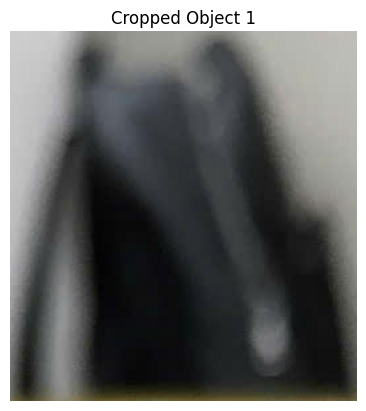

In [30]:
from PIL import Image
from ultralytics import YOLO
import os
import matplotlib.pyplot as plt

# Load a pretrained YOLOv8 model
model = YOLO("yolov8x.pt")  # Use "yolov8n.pt" for smaller model, "yolov8x.pt" for larger

# Load your image
image_path = "img_test_1.jpg"
image = Image.open(image_path)

# Perform object detection
results = model.predict(image)

# Extract bounding boxes, labels, and confidence scores
boxes = results[0].boxes.xyxy.tolist()  # Bounding box coordinates (x1, y1, x2, y2)
confidences = results[0].boxes.conf.tolist()  # Confidence scores
class_ids = results[0].boxes.cls.tolist()  # Class IDs (e.g., 0 for "person", 2 for "car")

# Create a directory to save cropped objects
os.makedirs("cropped_objects", exist_ok=True)

# Crop and save detected objects
cropped_images = []
for i, (box, conf, cls_id) in enumerate(zip(boxes, confidences, class_ids)):
    x1, y1, x2, y2 = map(int, box)
    cropped_image = image.crop((x1, y1, x2, y2))
    cropped_image.save(f"cropped_objects/object_{i}.jpg")
    cropped_images.append(cropped_image)

print(f"Cropped {len(boxes)} objects!")

# Display cropped images
for i, cropped_image in enumerate(cropped_images):
    plt.figure()
    plt.imshow(cropped_image)
    plt.title(f"Cropped Object {i}")
    plt.axis('off')
    plt.show()




0: 640x320 1 cup, 66.0ms
Speed: 17.7ms preprocess, 66.0ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 320)
Cropped 1 objects!


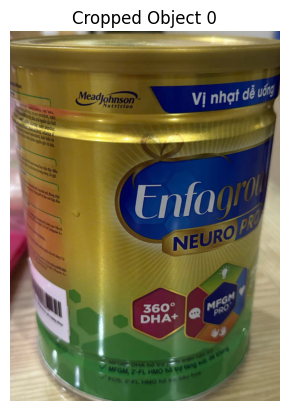

In [39]:
from PIL import Image
from ultralytics import YOLO
import os
import matplotlib.pyplot as plt

def detect_and_crop_objects(image_path):
    # Load a pretrained YOLOv8 model
    model = YOLO("yolov8n.pt")  # Use "yolov8n.pt" for smaller model, "yolov8x.pt" for larger

    # Load your image
    image = Image.open(image_path)

    # Perform object detection
    results = model.predict(image)

    # Extract bounding boxes, labels, and confidence scores
    boxes = results[0].boxes.xyxy.tolist()  # Bounding box coordinates (x1, y1, x2, y2)
    confidences = results[0].boxes.conf.tolist()  # Confidence scores
    class_ids = results[0].boxes.cls.tolist()  # Class IDs (e.g., 0 for "person", 2 for "car")

    # Create a directory to save cropped objects
    os.makedirs("cropped_objects", exist_ok=True)

    # Crop and save detected objects
    cropped_images = []
    for i, (box, conf, cls_id) in enumerate(zip(boxes, confidences, class_ids)):
        x1, y1, x2, y2 = map(int, box)
        cropped_image = image.crop((x1, y1, x2, y2))
        cropped_image.save(f"cropped_objects/object_{i}.jpg")
        cropped_images.append(cropped_image)

    print(f"Cropped {len(boxes)} objects!")

    # Display cropped images
    for i, cropped_image in enumerate(cropped_images):
        plt.figure()
        plt.imshow(cropped_image)
        plt.title(f"Cropped Object {i}")
        plt.axis('off')
        plt.show()

# Example usage
detect_and_crop_objects("img_test_1.jpg")

In [33]:
detect_and_crop_objects("img_test_2.jpg")


0: 640x480 (no detections), 691.7ms
Speed: 1.6ms preprocess, 691.7ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 480)
Cropped 0 objects!



0: 640x320 1 tv, 2 mouses, 1 keyboard, 387.8ms
Speed: 1.2ms preprocess, 387.8ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 320)
Cropped 4 objects!


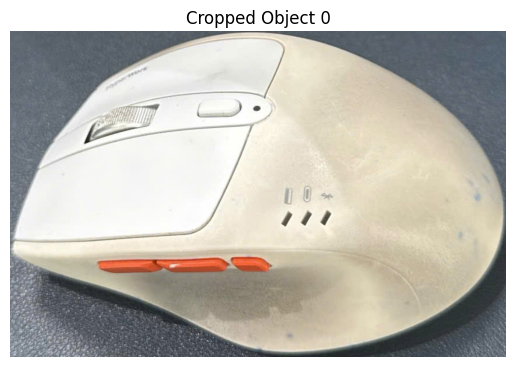

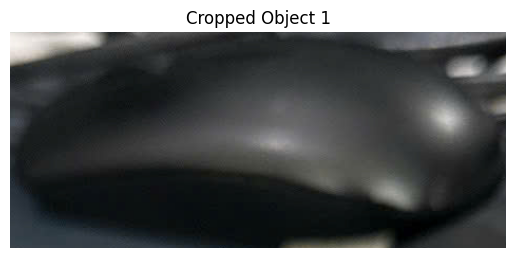

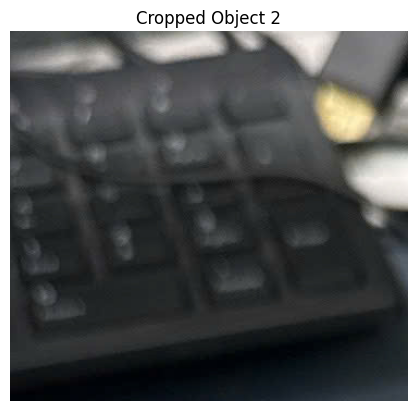

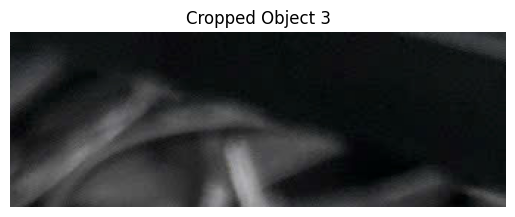

In [34]:
detect_and_crop_objects("img_test_3.jpg")


0: 480x640 2 tvs, 3 mouses, 2 keyboards, 65.2ms
Speed: 2.2ms preprocess, 65.2ms inference, 0.8ms postprocess per image at shape (1, 3, 480, 640)
Cropped 7 objects!


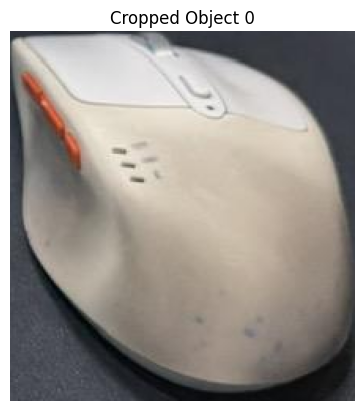

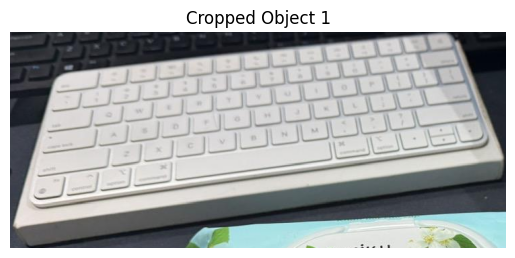

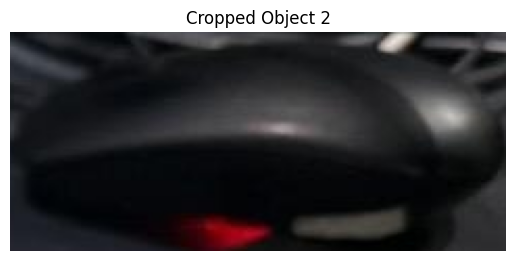

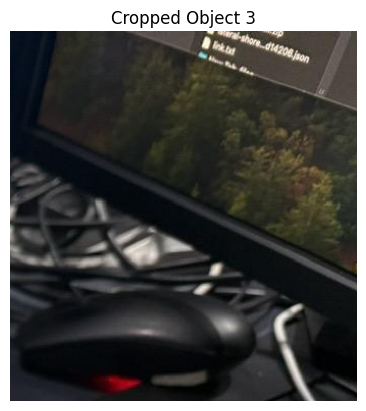

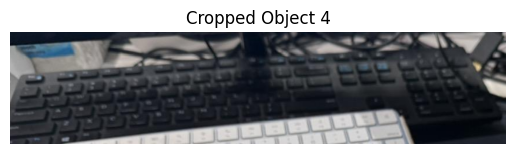

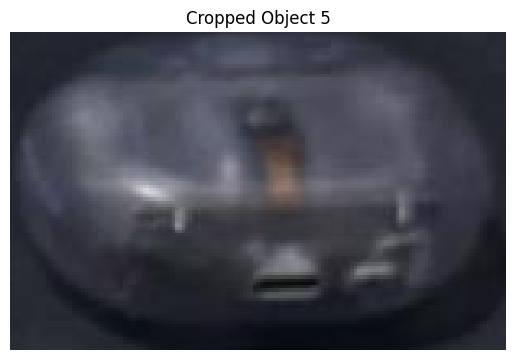

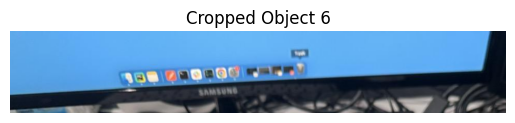

In [42]:
detect_and_crop_objects("img_test_16.jpg")